# Reddit Hyperlink Network  Link Prediction Pipeline 
 

## 1. Load and combining BOTH datasets

In [1]:
import pandas as pd
import networkx as nx

df_body  = pd.read_csv('2ndfiles/soc-redditHyperlinks-body.tsv',  sep='\t')
df_title = pd.read_csv('2ndfiles/soc-redditHyperlinks-title.tsv', sep='\t')

df_body['source_file']  = 'body'
df_title['source_file'] = 'title'

df = pd.concat([df_body, df_title], ignore_index=True)

print(f"Body edges:  {len(df_body)}")
print(f"Title edges: {len(df_title)}")
print(f"Total edges: {len(df)}")

Body edges:  286561
Title edges: 571927
Total edges: 858488


In [2]:
# Build ONE graph from combined data (fix: removed duplicate block)
G = nx.from_pandas_edgelist(
    df,
    source='SOURCE_SUBREDDIT',
    target='TARGET_SUBREDDIT',
    create_using=nx.DiGraph()
)
G_und = G.to_undirected()
print(f"Nodes: {G_und.number_of_nodes()}, Edges: {G_und.number_of_edges()}")

Nodes: 67180, Edges: 309667


## 2. Load embeddings

In [3]:
cols = ["SUBREDDIT"] + list(range(300))
emb  = pd.read_csv("2ndfiles/web-redditEmbeddings-subreddits.csv", names=cols)
emb  = emb.set_index("SUBREDDIT")

print(emb.shape)
print(emb.loc["leagueoflegends"][:5])

(51278, 300)
0   -2.785298
1   -0.166391
2    1.592624
3   -1.269829
4    2.861522
Name: leagueoflegends, dtype: float64


## 3. Edge feature helpers

In [4]:
import numpy as np

def edge_feature_hadamard(u, v):
    """Element-wise product (original)."""
    return emb.loc[u].values * emb.loc[v].values

def edge_feature_concat(u, v):
    """Concatenation of both embeddings -> 600-dim."""
    return np.concatenate([emb.loc[u].values, emb.loc[v].values])

def edge_feature_absdiff(u, v):
    """Absolute difference -> 300-dim."""
    return np.abs(emb.loc[u].values - emb.loc[v].values)

## 4. Split edges BEFORE sampling negatives
 prevents the same edges appearing in both train & test

In [5]:
from sklearn.model_selection import train_test_split

all_edges = [(u, v) for u, v in G_und.edges()
             if u in emb.index and v in emb.index]

train_pos_edges, test_pos_edges = train_test_split(
    all_edges, test_size=0.2, random_state=42
)

print(f"Train positive edges: {len(train_pos_edges)}")
print(f"Test  positive edges: {len(test_pos_edges)}")

Train positive edges: 199744
Test  positive edges: 49937


## 5. Negative sampling (clean)
 no self-loops, no duplicates, no overlap with positives

In [6]:
import random

nodes   = list(emb.index)
all_pos = set(all_edges) | {(v, u) for u, v in all_edges}

def sample_neg_edges(n, exclude_set):
    neg = set()
    while len(neg) < n:
        u, v = random.sample(nodes, 2)
        if u != v and (u, v) not in exclude_set and (v, u) not in exclude_set:
            neg.add((u, v))
    return list(neg)

train_neg_edges = sample_neg_edges(len(train_pos_edges), all_pos)
test_neg_edges  = sample_neg_edges(
    len(test_pos_edges),
    all_pos | set(train_neg_edges) | {(v, u) for u, v in train_neg_edges}
)

print(f"Train negative edges: {len(train_neg_edges)}")
print(f"Test  negative edges: {len(test_neg_edges)}")

Train negative edges: 199744
Test  negative edges: 49937


## 6. Baseline: Jaccard similarity
  adds a classical structural baseline for comparison

In [7]:
from sklearn.metrics import roc_auc_score

def jaccard_score_edge(u, v, graph):
    try:
        gen = nx.jaccard_coefficient(graph, [(u, v)])
        _, _, score = next(gen)
        return score
    except Exception:
        return 0.0

test_edges_all  = test_pos_edges + test_neg_edges
test_labels_all = [1]*len(test_pos_edges) + [0]*len(test_neg_edges)

jaccard_scores = [jaccard_score_edge(u, v, G_und) for u, v in test_edges_all]
jaccard_auc    = roc_auc_score(test_labels_all, jaccard_scores)
print(f"Jaccard Baseline AUC: {jaccard_auc:.4f}")

Jaccard Baseline AUC: 0.9430


## 7. Embedding-based classifier (Logistic Regression)
  trained on train edges, evaluated on unseen test edges; three feature types compared

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

def build_xy(pos_edges, neg_edges, feat_fn):
    X, y = [], []
    for u, v in pos_edges:
        feat = feat_fn(u, v)
        if feat is not None:
            X.append(feat); y.append(1)
    for u, v in neg_edges:
        feat = feat_fn(u, v)
        if feat is not None:
            X.append(feat); y.append(0)
    return np.array(X), np.array(y)

results = {}
for name, fn in [("Hadamard", edge_feature_hadamard),
                 ("Concat",   edge_feature_concat),
                 ("AbsDiff",  edge_feature_absdiff)]:

    X_tr, y_tr = build_xy(train_pos_edges, train_neg_edges, fn)
    X_te, y_te = build_xy(test_pos_edges,  test_neg_edges,  fn)

    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_tr, y_tr)

    preds = clf.predict_proba(X_te)[:, 1]
    auc   = roc_auc_score(y_te, preds)
    results[f"LR-{name}"] = auc
    print(f"\nLogistic Regression ({name})")
    print(f"  AUC: {auc:.4f}")
    print(classification_report(y_te, clf.predict(X_te)))

lr_auc = max(results.values())


Logistic Regression (Hadamard)
  AUC: 0.9615
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     49937
           1       0.95      0.85      0.90     49937

    accuracy                           0.90     99874
   macro avg       0.91      0.90      0.90     99874
weighted avg       0.91      0.90      0.90     99874


Logistic Regression (Concat)
  AUC: 0.9601
              precision    recall  f1-score   support

           0       0.88      0.93      0.90     49937
           1       0.93      0.87      0.90     49937

    accuracy                           0.90     99874
   macro avg       0.90      0.90      0.90     99874
weighted avg       0.90      0.90      0.90     99874


Logistic Regression (AbsDiff)
  AUC: 0.9249
              precision    recall  f1-score   support

           0       0.82      0.91      0.86     49937
           1       0.90      0.81      0.85     49937

    accuracy                           0.86    

## 8. GNN with proper train/test split
  GNN trained on train edges only, evaluated on held-out test edges

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data  import Data
from torch_geometric.nn    import GCNConv
from torch_geometric.utils import negative_sampling

print("PyTorch version:", torch.__version__)
print("All imports successful!")

c:\Users\Paridhi Kotarya\OneDrive\Documents\GitHub\social-network-interactions\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.11.0+cpu
All imports successful!


In [10]:
common_nodes = [n for n in G_und.nodes() if n in emb.index]
node_index   = {n: i for i, n in enumerate(common_nodes)}

x = torch.tensor(emb.loc[common_nodes].values, dtype=torch.float)

# Training edges only — no test leakage
train_ei = torch.tensor(
    [[node_index[u] for u, v in train_pos_edges if u in node_index and v in node_index],
     [node_index[v] for u, v in train_pos_edges if u in node_index and v in node_index]],
    dtype=torch.long
)

# Test edge index lists for evaluation only
test_pos_idx = [(node_index[u], node_index[v])
                for u, v in test_pos_edges
                if u in node_index and v in node_index]
test_neg_idx = [(node_index[u], node_index[v])
                for u, v in test_neg_edges
                if u in node_index and v in node_index]

data = Data(x=x, edge_index=train_ei)
print(f"GNN data — Nodes: {data.num_nodes}, Train edges: {data.num_edges}")

GNN data — Nodes: 31238, Train edges: 199744


In [11]:
class GCN(nn.Module):
    def __init__(self, in_ch, hidden_ch, out_ch):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden_ch)
        self.conv2 = GCNConv(hidden_ch, out_ch)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        return self.conv2(x, edge_index)

model     = GCN(300, 128, 64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
print(model)

GCN(
  (conv1): GCNConv(300, 128)
  (conv2): GCNConv(128, 64)
)


In [12]:
def train_step():
    model.train()
    optimizer.zero_grad()
    z = model(data.x, data.edge_index)

    pos_edge = data.edge_index
    neg_edge = negative_sampling(
        edge_index=data.edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=pos_edge.size(1)
    )

    pos_score = (z[pos_edge[0]] * z[pos_edge[1]]).sum(dim=1)
    neg_score = (z[neg_edge[0]] * z[neg_edge[1]]).sum(dim=1)

    loss = (
        -torch.log(torch.sigmoid(pos_score) + 1e-15).mean()
        -torch.log(1 - torch.sigmoid(neg_score) + 1e-15).mean()
    )
    loss.backward()
    optimizer.step()
    return loss.item()

for epoch in range(50):
    loss = train_step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")

Epoch 000 | Loss: 1.9811
Epoch 010 | Loss: 1.0354
Epoch 020 | Loss: 1.0029
Epoch 030 | Loss: 0.9784
Epoch 040 | Loss: 0.9700


In [13]:
# Evaluate on held-out test edges only
model.eval()
with torch.no_grad():
    z = model(data.x, data.edge_index)

def to_tensor_idx(edge_list):
    return torch.tensor(edge_list, dtype=torch.long).t().contiguous()

pos_ei = to_tensor_idx(test_pos_idx)
neg_ei = to_tensor_idx(test_neg_idx)

pos_score = torch.sigmoid((z[pos_ei[0]] * z[pos_ei[1]]).sum(dim=1))
neg_score = torch.sigmoid((z[neg_ei[0]] * z[neg_ei[1]]).sum(dim=1))

scores = torch.cat([pos_score, neg_score]).numpy()
labels = torch.cat([torch.ones(len(test_pos_idx)),
                    torch.zeros(len(test_neg_idx))]).numpy()

gnn_auc = roc_auc_score(labels, scores)
print(f"GNN AUC (on held-out test edges): {gnn_auc:.4f}")

GNN AUC (on held-out test edges): 0.8915


## 9. Summary comparison

In [16]:
 
print("Method                    AUC")
 
print(f"Jaccard Baseline          {jaccard_auc:.4f}")
for name, auc in results.items():
    print(f"{name:<26}{auc:.4f}")
print(f"GNN (held-out eval)       {gnn_auc:.4f}")
 
print(f"Best LR vs GNN gain:      {gnn_auc - lr_auc:+.4f}")

Method                    AUC
Jaccard Baseline          0.9430
LR-Hadamard               0.9615
LR-Concat                 0.9601
LR-AbsDiff                0.9249
GNN (held-out eval)       0.8915
Best LR vs GNN gain:      -0.0700


## 10. t-SNE colored by Louvain community
 nodes colored by detected community 
 

C:\Users\Paridhi Kotarya\AppData\Local\Temp\ipykernel_22704\2608782229.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap      = cm.get_cmap('tab20', num_comms)


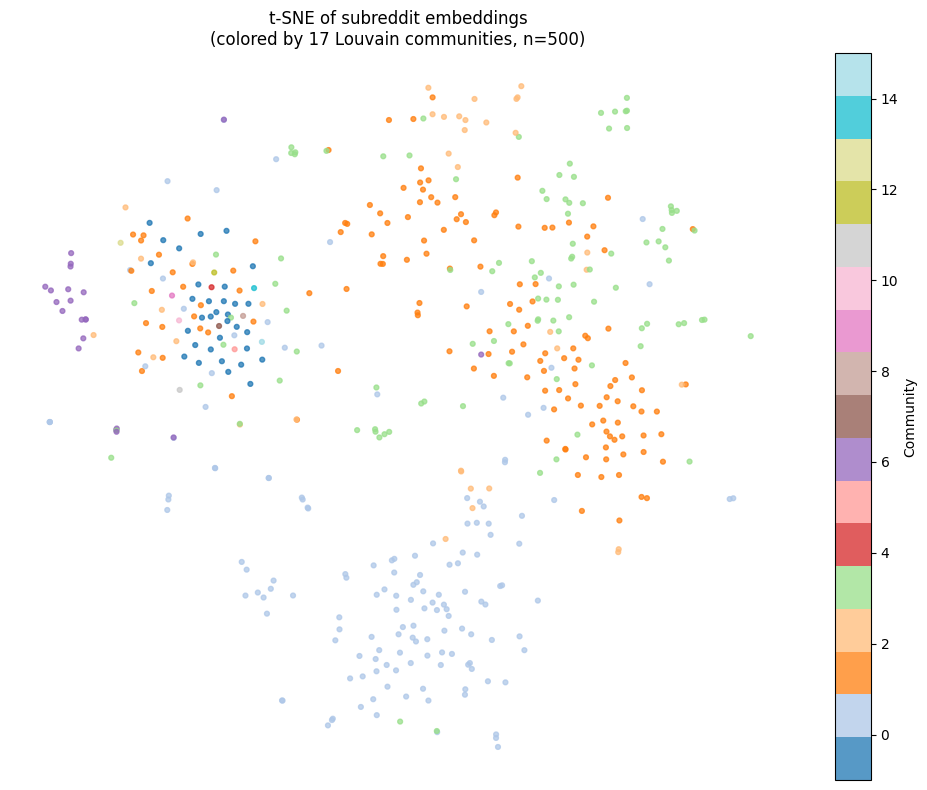

In [17]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import community as community_louvain    
sample_nodes = list(emb.index[:500])
subgraph     = G_und.subgraph(sample_nodes)

partition = community_louvain.best_partition(subgraph)
comm_ids  = [partition.get(n, -1) for n in sample_nodes]
num_comms = len(set(comm_ids))
cmap      = cm.get_cmap('tab20', num_comms)

vectors = emb.loc[sample_nodes].values
coords  = TSNE(n_components=2, random_state=42).fit_transform(vectors)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    coords[:, 0], coords[:, 1],
    c=comm_ids, cmap=cmap,
    s=12, alpha=0.75
)
plt.colorbar(scatter, label='Community')
plt.title(f"t-SNE of subreddit embeddings\n"
          f"(colored by {num_comms} Louvain communities, n=500)")
plt.axis('off')
plt.tight_layout()
plt.savefig('tsne_communities.png', dpi=150)
plt.show()
 